In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("../student_performance_clean.csv")

In [5]:
data.head()

,student_id,study_hours,attendance,previous_score,sleep_hours,assignments,practice_tests,final_score
0,S0001,5.8,84.2,49.5,7.0,5.0,8.0,53.7
1,S0002,3.1,71.1,61.2,7.5,7.0,2.0,61.4
2,S0003,6.7,93.3,73.9,6.7,7.0,0.0,68.2
3,S0004,7.1,70.5,66.6,6.5,8.0,6.0,69.8
4,S0005,1.3,70.4,58.9,7.1,3.0,4.0,38.6


In [6]:
data.describe()

,study_hours,attendance,previous_score,sleep_hours,assignments,practice_tests,final_score
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000
mean,5.150333,77.697250,66.921500,6.945500,6.120000,3.926667,62.55600
std,1.927760,11.573468,14.295495,1.088648,2.554044,2.512996,12.79827
min,0.500000,45.000000,26.600000,4.000000,2.000000,0.000000,22.40000
25%,3.800000,70.475000,57.900000,6.200000,4.000000,2.000000,53.90000
50%,5.200000,78.150000,67.400000,7.000000,6.000000,4.000000,62.20000
75%,6.400000,85.400000,76.425000,7.700000,8.000000,6.000000,71.50000
max,10.000000,100.000000,98.000000,10.000000,10.000000,8.000000,100.00000


In [7]:
# EDA

In [8]:
# X and y

In [9]:
# Train/test split

In [10]:
# Linear Regression

In [11]:
X = data[
    [
        "study_hours",
        "attendance",
        "previous_score",
        "sleep_hours",
        "assignments",
        "practice_tests"
    ]
]

y = data["final_score"]

In [12]:
y.head()

0    53.7
1    61.4
2    68.2
3    69.8
4    38.6
Name: final_score, dtype: float64

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 6)
y shape: (600,)


In [14]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (480, 6)
X_test: (120, 6)
y_train: (480,)
y_test: (120,)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
X_train: (480, 6)
X_test: (120, 6)
y_train: (480,)
y_test: (120,)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
print("Intercept:", model.intercept_)

Intercept: -28.411277567667547


In [25]:
print("Coefficients:", model.coef_)

Coefficients: [2.00403512 0.12967693 0.74188955 1.41705021 1.15693532 1.01722574]


In [26]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,study_hours,2.004035
1,attendance,0.129677
2,previous_score,0.741890
3,sleep_hours,1.417050
4,assignments,1.156935
5,practice_tests,1.017226


In [27]:
predictions = model.predict(X_test)

In [28]:
predictions[:10]

array([53.2003899 , 61.49708892, 63.92229205, 83.86861226, 36.62647515,
       71.52860001, 75.33627183, 45.21666971, 77.39624764, 66.54575848])

In [29]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": predictions
})

comparison.head(10)

,Actual Score,Predicted Score
0,59.1,53.200390
1,57.9,61.497089
2,60.5,63.922292
3,81.4,83.868612
4,38.8,36.626475
5,69.9,71.528600
6,78.3,75.336272
7,45.2,45.216670
8,74.0,77.396248
9,65.0,66.545758


In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 4.197656308334869


In [31]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

MSE: 28.866561889855014


In [32]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5.372761104856144


In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.197656308334869
MSE: 28.866561889855014
RMSE: 5.372761104856144
R² Score: 0.7746033664135803


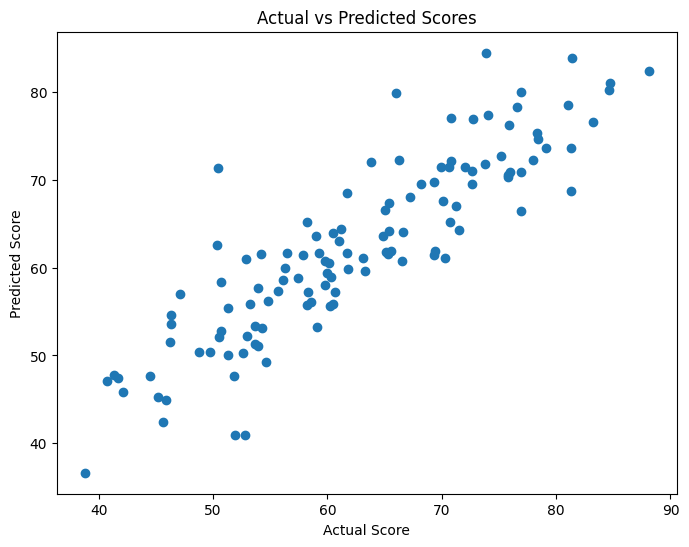

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.show()

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.197656308334869
MSE: 28.866561889855014
RMSE: 5.372761104856144
R² Score: 0.7746033664135803


In [36]:
from sklearn.tree import DecisionTreeRegressor

In [37]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

In [38]:
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [39]:
tree_predictions = tree_model.predict(X_test)

In [40]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree")
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Decision Tree
MAE: 6.079166666666667
MSE: 58.107749999999996
RMSE: 7.62284395747414
R²: 0.5462815667048924


In [41]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [43]:
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
forest_predictions = forest_model.predict(X_test)

In [45]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_mse = mean_squared_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(forest_mse)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest")
print("MAE:", forest_mae)
print("MSE:", forest_mse)
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

Random Forest
MAE: 4.364233333333334
MSE: 30.9083890666667
RMSE: 5.559531371137922
R²: 0.7586603187525992


In [46]:
tree_train_predictions = tree_model.predict(X_train)

tree_train_r2 = r2_score(
    y_train,
    tree_train_predictions
)

print("Decision Tree training R²:", tree_train_r2)

Decision Tree training R²: 1.0


In [47]:
forest_train_predictions = forest_model.predict(X_train)

forest_train_r2 = r2_score(
    y_train,
    forest_train_predictions
)

print("Random Forest training R²:", forest_train_r2)

Random Forest training R²: 0.9706930271964147


In [48]:
linear_train_predictions = model.predict(X_train)

linear_train_r2 = r2_score(
    y_train,
    linear_train_predictions
)

print("Linear Regression training R²:", linear_train_r2)

Linear Regression training R²: 0.86706519325184


In [49]:
pip install xgboost

     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     -------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
     -------------------------------------- 0.0/101.7 MB 495.5 kB/s eta 0:03:26
     -------------------------------------- 0.1/101.7 MB 751.6 kB/s eta 0:02:16
     -------------------------------------- 0.2/101.7 MB 984.6 kB/s eta 0:01:44
     ---------------------------------------- 0.2/101.7 MB 1.1 MB/s eta 0:01:36
     ---------------------------------------- 0.3/101.7 MB 1.4 MB/s eta 0:01:15
     ---------------------------------------- 0.4/101.7 MB 1.6 MB/s eta 0:01:03
     ---------------------------------------- 0.6/101.7 MB 1.9 MB/s eta 0:00:54
     ---------------------------------------- 0.7/101.7 MB 1.9 MB/s eta 0:00:53
     ---------------------------------------- 0.9/101.7 MB 2.2 MB/s eta 0:00:47
     ---------------------------------------- 1.0/101.7 MB 2.3 MB/s eta 0:00:44
     ---------------------------------------- 1


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from xgboost import XGBRegressor

In [51]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [52]:
xgb_predictions = xgb_model.predict(X_test)

NotFittedError: need to call fit or load_model beforehand

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

In [53]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from xgboost import XGBRegressor

In [55]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [56]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [57]:
xgb_predictions = xgb_model.predict(X_test)

In [58]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

XGBoost
MAE: 4.490933685302735
MSE: 32.579344472743585
RMSE: 5.707831853930491
R²: 0.7456131216239685


In [59]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

cv_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:")
print(cv_scores)

print("\nMean R²:")
print(cv_scores.mean())

Cross-validation R² scores:
[0.88489864 0.85973191 0.82836799 0.86156634 0.87221265]

Mean R²:
0.8613555049084181


In [60]:
from sklearn.model_selection import cross_val_score

In [61]:
cv_model = LinearRegression()

In [62]:
cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

In [63]:
print("Cross-validation R² scores:")
print(cv_scores)

print("\nMean R²:")
print(cv_scores.mean())

Cross-validation R² scores:
[0.88489864 0.85973191 0.82836799 0.86156634 0.87221265]

Mean R²:
0.8613555049084181


In [64]:
rf_cv_scores = cross_val_score(
    forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R²:", rf_cv_scores)
print("Random Forest Mean R²:", rf_cv_scores.mean())

Random Forest CV R²: [0.83781038 0.79420537 0.74959994 0.79234767 0.8049886 ]
Random Forest Mean R²: 0.7957903906187911


In [65]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("XGBoost CV R²:", xgb_cv_scores)
print("XGBoost Mean R²:", xgb_cv_scores.mean())

XGBoost CV R²: [0.83112745 0.82804856 0.74995153 0.8065501  0.83467252]
XGBoost Mean R²: 0.8100700298486293


In [66]:
tree_cv_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Decision Tree CV R²:", tree_cv_scores)
print("Decision Tree Mean R²:", tree_cv_scores.mean())

Decision Tree CV R²: [0.588592   0.5926233  0.48196023 0.64580746 0.59765356]
Decision Tree Mean R²: 0.5813273097174158


In [67]:
linear_cv_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R²:", linear_cv_scores)
print("Linear Regression Mean R²:", linear_cv_scores.mean())

Linear Regression CV R²: [0.88489864 0.85973191 0.82836799 0.86156634 0.87221265]
Linear Regression Mean R²: 0.8613555049084181


In [68]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

In [69]:
from sklearn.model_selection import GridSearchCV

In [70]:
xgb_base = XGBRegressor(
    random_state=42
)

In [71]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [72]:
grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [73]:
print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300}


In [74]:
print("Best CV R²:")
print(grid_search.best_score_)

Best CV R²:
0.8283950992358987


In [75]:
best_xgb = grid_search.best_estimator_

In [76]:
tuned_predictions = best_xgb.predict(X_test)

In [77]:
tuned_mae = mean_absolute_error(y_test, tuned_predictions)

tuned_mse = mean_squared_error(y_test, tuned_predictions)

tuned_rmse = np.sqrt(tuned_mse)

tuned_r2 = r2_score(y_test, tuned_predictions)

print("Tuned XGBoost")
print("MAE:", tuned_mae)
print("MSE:", tuned_mse)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

Tuned XGBoost
MAE: 4.497901662190755
MSE: 32.503953458192605
RMSE: 5.701223856172691
R²: 0.7462017916896069


In [78]:
final_model = LinearRegression()

final_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
final_predictions = final_model.predict(X_test)

In [80]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Model Performance")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R²:", final_r2)

Final Model Performance
MAE: 4.197656308334869
RMSE: 5.372761104856144
R²: 0.7746033664135803


In [81]:
import joblib

In [82]:
joblib.dump(
    final_model,
    "../models/student_score_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/student_score_model.pkl'

In [83]:
import joblib

joblib.dump(
    final_model,
    "../models/student_score_model.pkl"
)

['../models/student_score_model.pkl']

In [84]:
loaded_model = joblib.load(
    "../models/student_score_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [85]:
test_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Predicted score:", test_prediction[0])

Predicted score: 53.20038990330533
